# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset.

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [7]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# Inspect the shapes of the datasets
print("X_train shape: " + str(X_train.shape)
    + "\ny_train shape: " + str(y_train.shape)
    + "\nX_test shape: " + str(X_test.shape)
    + "\ny_test shape: " + str(y_test.shape)
      )

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

#From class_names, we know there will be 10 possibilities of categories. Alternatively can just use the length.
y_train_onehot = to_categorical(y_train, len(class_names))
y_test_onehot = to_categorical(y_test, len(class_names))


X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


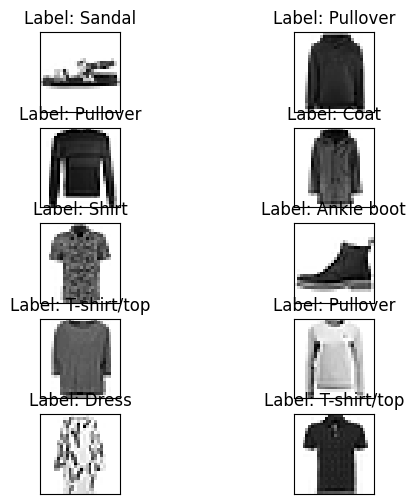

In [11]:
import matplotlib.pyplot as plt
# Verify the data looks as expected


import numpy as np
# Selecting 10 random indices
random_indices = np.random.choice(len(X_train), 10, replace=False)


# Creating a 5x2 grid plot
fig, axes = plt.subplots(5, 2, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[random_indices[i]], cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f"Label: {class_names[y_train[random_indices[i]]]}")

    # Removing axis labels
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

The data appears as expected - greyscale images of clothing items. It's much easier to distinguish what the images should be classified, especially compared to the low resolution of the MNIST dataset images.
AFter rerunning the random sample of images a few times, I can see some images being potentially difficult to predict classification because some of the categories appear to overlap (coat, pullover, and shirt). However at first glance I don't see any obvious issues with the data.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [12]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape = (28,28))) # Putting input_shape as 28x28 in Flatten, since the images are 28x28 pixels.
model.add(Dense(10, activation='softmax')) # 10 neurons, softmax activation


# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)

# Train the model with `model.fit()`
model.fit(
    X_train, # Training data
    y_train_onehot, # Training labels - updated for onehot encoding
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)

# Evaluate the model with `model.evaluate()`
loss, accuracy = model.evaluate(X_test, y_test_onehot)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6213 - loss: 1.1675 - val_accuracy: 0.7858 - val_loss: 0.6624
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.7930 - loss: 0.6355 - val_accuracy: 0.8077 - val_loss: 0.5823
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8144 - loss: 0.5693 - val_accuracy: 0.8200 - val_loss: 0.5457
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8239 - loss: 0.5397 - val_accuracy: 0.8214 - val_loss: 0.5243
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8300 - loss: 0.5143 - val_accuracy: 0.8254 - val_loss: 0.5109
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8229 - loss: 0.5253
Loss:     0.53
Accuracy: 81.83%


Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

The model is providing about 82% accuracy which isn't horrible, but not reliable enough - we would want a higher accuracy value on the test set.

Given the simplicity of the model, I am actually surprised it's holding up better compared to other accuracy scores from the labs models. The performance of the model shows that even a simple model like this can learn, but appears to be limited in improving further (to achieve an accuracy in 95%+ range).

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [13]:
from keras.layers import Conv2D

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, 3, activation='relu', input_shape = (28,28,1)))
model.add(Flatten()) #Flattern with no parameters
model.add(Dense(64, activation='relu')) # 64 neurons, ReLU activation
model.add(Dense(10, activation='softmax')) # 10 neurons, softmax activation


# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)


# Train the model
model.fit(
    X_train, # Training data
    y_train_onehot, # Training labels - updated for onehot encoding
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)


# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_onehot)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6915 - loss: 0.9038 - val_accuracy: 0.8196 - val_loss: 0.5061
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.8280 - loss: 0.4841 - val_accuracy: 0.8444 - val_loss: 0.4462
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.8463 - loss: 0.4315 - val_accuracy: 0.8382 - val_loss: 0.4606
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.8580 - loss: 0.3948 - val_accuracy: 0.8602 - val_loss: 0.3936
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.8693 - loss: 0.3692 - val_accuracy: 0.8639 - val_loss: 0.3782
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8599 - loss: 0.3917
Loss:     0.40
Accuracy: 85.57%


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

The CNN model performed better than the baseline model, with an accuracy of almost 86%. From the previous linear model, there is an improvement by just under 5%.

This improvement in performance is likely attributed to how convolutional neural networks are effective at processing image clasification tasks like this one. Also setting up the parameters to take in an image with the specific dimensions of the images from the dataset also the dataset to fine tune further.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [17]:
# A. Test Hyperparameters

#Will choose to test filters, set up different values to test
test_filters = [32, 64, 128]
filters_results = []

#FOr each test_Filters , build, compile, train models, and then store results.
for filters in test_filters:

    #Create model, build off of previous Conv2D one:
    model = Sequential()
    model.add(Conv2D(filters, 3, activation='relu', input_shape = (28,28,1)))
    model.add(Flatten()) #Flattern with no parameters
    model.add(Dense(64, activation='relu')) # 64 neurons, ReLU activation
    model.add(Dense(10, activation='softmax')) # 10 neurons, softmax activation


    # Compile the model using `model.compile()`
    model.compile(
        loss='categorical_crossentropy', # Loss function
        optimizer='sgd', # Optimizer
        metrics=['accuracy'] # Metrics to evaluate the model
    )


    # Train the model
    model.fit(
        X_train, # Training data
        y_train_onehot, # Training labels - updated for onehot encoding
        epochs=5, # Number of epochs
        batch_size=32, # Number of samples per batch
        validation_split=0.2 # Use 20% of the data for validation
    )

    # Evaluate the model, store results
    loss, accuracy = model.evaluate(X_test, y_test_onehot)
    filters_results.append({
        'filters': filters,
        'loss': loss,
        'accuracy': accuracy
    })

    print(f'Model - ' + 'Filter #: ' + str(filters))
    print(f'Loss:     {loss:.2f}')
    print(f'Accuracy: {accuracy*100:.2f}%')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6993 - loss: 0.9082 - val_accuracy: 0.8222 - val_loss: 0.4943
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.8229 - loss: 0.4845 - val_accuracy: 0.7727 - val_loss: 0.5880
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step - accuracy: 0.8458 - loss: 0.4304 - val_accuracy: 0.8493 - val_loss: 0.4229
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.8585 - loss: 0.3980 - val_accuracy: 0.8549 - val_loss: 0.4018
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.8692 - loss: 0.3683 - val_accuracy: 0.8471 - val_loss: 0.4098
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8431 - loss: 0.4254
Model - Filter #: 32
Loss:     0.43
Accuracy: 84.13%
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 38ms/step - accuracy: 0.6956 - loss: 0.8914 - val_accuracy: 0.8134 - val_loss: 0.5183
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.8291 - loss: 0.4

In [20]:
# B. Test presence or absence of regularization

#Will choose to test dropout as regularization technique, set up different values to test
from keras.layers import Dropout, Dense, Flatten, Conv2D
from keras.models import Sequential
test_dropout_switch = [True, False]
dropout_results = []

#For each test_dropout_rates, build, compile, train models, and then store results.
for dropout_switch in test_dropout_switch:

      #Create model, build off of previous Conv2D one:
      model = Sequential()
      model.add(Conv2D(64, 3, activation='relu', input_shape = (28,28,1)))  #Setting filters to 64 since it had the best results.
      if dropout_switch:
        model.add(Dropout(0.5))
      model.add(Flatten()) #Flattern with no parameters
      model.add(Dense(64, activation='relu')) # 64 neurons, ReLU activation
      model.add(Dense(10, activation='softmax')) # 10 neurons, softmax activation


      # Compile the model using `model.compile()`
      model.compile(
          loss='categorical_crossentropy', # Loss function
          optimizer='sgd', # Optimizer
          metrics=['accuracy'] # Metrics to evaluate the model
      )


      # Train the model
      model.fit(
          X_train, # Training data
          y_train_onehot, # Training labels - updated for onehot encoding
          epochs=5, # Number of epochs
          batch_size=32, # Number of samples per batch
          validation_split=0.2 # Use 20% of the data for validation
      )

      # Evaluate the model, store results
      loss, accuracy = model.evaluate(X_test, y_test_onehot)
      dropout_results.append({
          'filters': 128,
          'dropout_switch': str(dropout_switch),
          'loss': loss,
          'accuracy': accuracy
      })

      print(f'Model - ' + 'Filter #: ' + str(64) + ' Dropout On: ' + str(dropout_switch))
      print(f'Loss:     {loss:.2f}')
      print(f'Accuracy: {accuracy*100:.2f}%')

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 52ms/step - accuracy: 0.6833 - loss: 0.9133 - val_accuracy: 0.8215 - val_loss: 0.4968
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 53ms/step - accuracy: 0.8169 - loss: 0.5044 - val_accuracy: 0.8397 - val_loss: 0.4484
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 52ms/step - accuracy: 0.8353 - loss: 0.4597 - val_accuracy: 0.8472 - val_loss: 0.4216
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 53ms/step - accuracy: 0.8479 - loss: 0.4191 - val_accuracy: 0.8543 - val_loss: 0.4025
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - accuracy: 0.8597 - loss: 0.3885 - val_accuracy: 0.8647 - val_loss: 0.3803
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8621 - loss: 0.3967
Model - Filter #: 64 Dropout On: True
Loss:     0.40
Accuracy: 85.80%
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.7033 - loss: 0.8996 - val_accuracy: 0.8148 - val_loss: 0.5167
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0

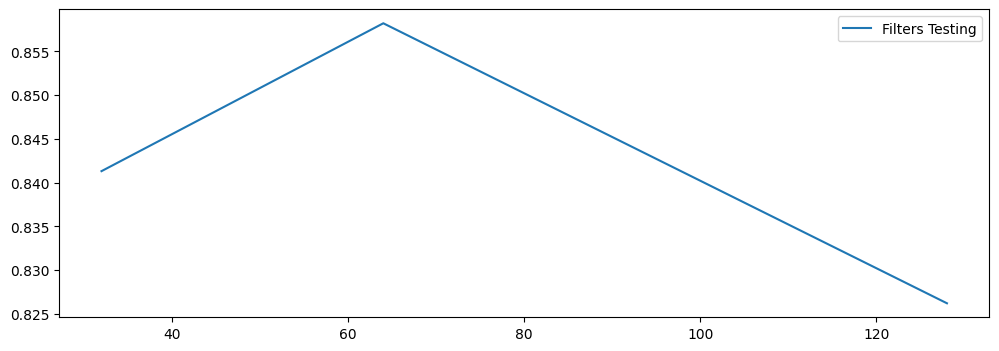

In [28]:
plt.figure(figsize=(12, 4))

#Get values from filters testing
filter_no = [value['filters'] for value in filters_results]
filter_acc = [value['accuracy'] for value in filters_results]

#Plot for filters comparison
plt.plot(filter_no, filter_acc,  label="Filters Testing")

plt.legend()
plt.show()

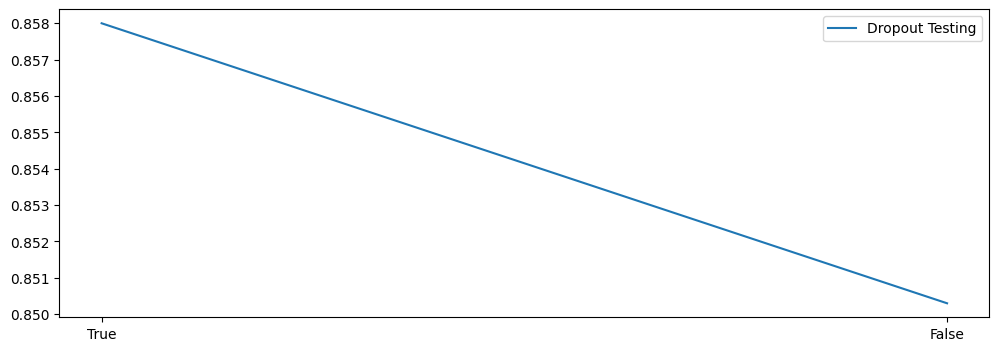

In [30]:
plt.figure(figsize=(12, 4))

#Get values from dropout testing
dropout_no = [value['dropout_switch'] for value in dropout_results]
dropout_acc = [value['accuracy'] for value in dropout_results]

#Plot for dropout comparison
plt.plot(dropout_no, dropout_acc,  label="Dropout Testing")

plt.legend()
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

Increasing the number of filters and turning on dropout appears to improve the accuracy of the models independently.

I think this improves the model because:
- the more layers the model has, the more things/patterns it can learn and identify to refine the final results
- from my understanding, dropout will turn off random neurons in layers so that it can see which one are actually the most impactful, and then can use it to determine the best dials/parameters for the models

The improvements are quite small overall, but the the best combination appears to set number of filters to 64, and to enable dropout.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [31]:
from keras.layers import Conv2D
from keras.layers import Dropout, Dense, Flatten, Conv2D
from keras.models import Sequential

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(64, 3, activation='relu', input_shape = (28,28,1))) #set filters to 64
model.add(Dropout(0.5)) #Added dropout layer
model.add(Flatten()) #Flattern with no parameters
model.add(Dense(64, activation='relu')) # 64 neurons, ReLU activation
model.add(Dense(10, activation='softmax')) # 10 neurons, softmax activation


# Compile the model using `model.compile()`
model.compile(
    loss='categorical_crossentropy', # Loss function
    optimizer='sgd', # Optimizer
    metrics=['accuracy'] # Metrics to evaluate the model
)


# Train the model
model.fit(
    X_train, # Training data
    y_train_onehot, # Training labels - updated for onehot encoding
    epochs=5, # Number of epochs
    batch_size=32, # Number of samples per batch
    validation_split=0.2 # Use 20% of the data for validation
)


# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test_onehot)

print(f'Loss:     {loss:.2f}')
print(f'Accuracy: {accuracy*100:.2f}%')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.6831 - loss: 0.9154 - val_accuracy: 0.8230 - val_loss: 0.5008
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 55ms/step - accuracy: 0.8104 - loss: 0.5208 - val_accuracy: 0.8049 - val_loss: 0.5132
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 53ms/step - accuracy: 0.8368 - loss: 0.4578 - val_accuracy: 0.8495 - val_loss: 0.4217
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 53ms/step - accuracy: 0.8438 - loss: 0.4345 - val_accuracy: 0.8529 - val_loss: 0.4078
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.8524 - loss: 0.4022 - val_accuracy: 0.8609 - val_loss: 0.3872
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8585 - loss: 0.4073
Loss:     0.41
Accuracy: 85.54%


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final model performance improved quite a bit from the original baseline model (81.83% vs 85.54%). I believe the improvement comes from tuning the filter size and dropout options to help the model fit better without over or underfitting.

However, the results are almost the same (actually a tiny bit worse) than the CNN model. It's possible the low number of epochs may have hindered the performance a bit - having a few more iterations could have helped train and tune the model better.

With more time I would probably test more filter sizes, number of layers, kernel sizes, and also other regularization techniques like L2.
I could also test these combinations with different optimizers like adam or different momentum values altogether.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.